In [32]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------- ----------------------- 3.4/8.3 MB 18.3 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 16.1 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 13.5 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   --- ------------------------------------ 2.9/36.6 MB 14.0 MB/s eta 0:00:03
   ---- ----------------------------------- 4.5/36.6 MB 11.2 MB/s eta 0:00:03
   ------ --------------------------------- 5.5/36.6 MB 9.3 MB/s eta 0:00:04
   -------- ------------------------------- 7.3/36.6 MB 9.1 MB/s eta 0:00:04
   ---------- ----------------------------- 10.0/36.6 MB 9.7 MB/s eta 0:00:03
   -------------- ------------------------- 13.1/36.6 MB 10.7 MB/s eta 0:00:03
   ----------------- ---------------------- 16.0/36.6 MB 11.3 MB/s eta 0:00:02
   -------------------- ------------------- 18.6/36.6 MB 11.4 MB/s eta 0:00:02
   -----

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

C:\Users\Avishkar anand pawar\.conda\envs\manufacturing\Lib\site-packages\requests\__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [3]:
#Loading the dataset

In [4]:
DATASET_PATH = r"C:\Data Science\NEU-DET"

TRAIN_IMAGES = os.path.join(
    DATASET_PATH,
    "train",
    "images"
)

VAL_IMAGES = os.path.join(
    DATASET_PATH,
    "validation",
    "images"
)

In [5]:
classes = [
    "crazing",
    "inclusion",
    "patches",
    "pitted_surface",
    "rolled-in_scale",
    "scratches"
]

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [7]:
# LOad training

In [8]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_IMAGES,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42
)

Found 1440 files belonging to 6 classes.


In [9]:
#load validation:

In [10]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_IMAGES,
    labels="inferred",
    label_mode="int",
    class_names=classes,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 360 files belonging to 6 classes.


In [11]:
#Create Augmentartion

In [12]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomFlip("horizontal"),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

In [13]:
#Build CNN:

In [14]:
model = keras.Sequential([
    
    layers.Input(
        shape=(224, 224, 3)
    ),
    
    # Data augmentation
    data_augmentation,
    
    # Normalize pixels
    layers.Rescaling(1./255),
    
    # First convolution block
    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),
    
    layers.MaxPooling2D(
        (2, 2)
    ),
    
    # Second convolution block
    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),
    
    layers.MaxPooling2D(
        (2, 2)
    ),
    
    # Third convolution block
    layers.Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),
    
    layers.MaxPooling2D(
        (2, 2)
    ),
    
    # Convert feature maps to vector
    layers.Flatten(),
    
    # Fully connected layer
    layers.Dense(
        128,
        activation="relu"
    ),
    
    # Reduce overfitting
    layers.Dropout(0.5),
    
    # Six defect classes
    layers.Dense(
        6,
        activation="softmax"
    )
])

In [15]:
#Display model:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
#Compile the model:
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    
    loss="sparse_categorical_crossentropy",
    
    metrics=["accuracy"]
)

In [18]:
#Train the baseline CNN

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20


C:\Users\Avishkar anand pawar\.conda\envs\manufacturing\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


45/45 ━━━━━━━━━━━━━━━━━━━━ 46s 958ms/step - accuracy: 0.2535 - loss: 1.7442 - val_accuracy: 0.3944 - val_loss: 1.4585
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.4125 - loss: 1.3387 - val_accuracy: 0.5250 - val_loss: 1.1267
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 73s 2s/step - accuracy: 0.5604 - loss: 1.1274 - val_accuracy: 0.6806 - val_loss: 1.0061
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.6660 - loss: 0.9794 - val_accuracy: 0.7028 - val_loss: 0.9066
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.7160 - loss: 0.8290 - val_accuracy: 0.7306 - val_loss: 0.8592
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.7958 - loss: 0.6373 - val_accuracy: 0.7472 - val_loss: 0.7859
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.6653 - loss: 0.9108 - val_accuracy: 0.5583 - val_loss: 0.9805
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7076 - loss: 0.8437 - val_accuracy: 0.7333 - val_loss: 0.8356


In [20]:
#Plot training performance

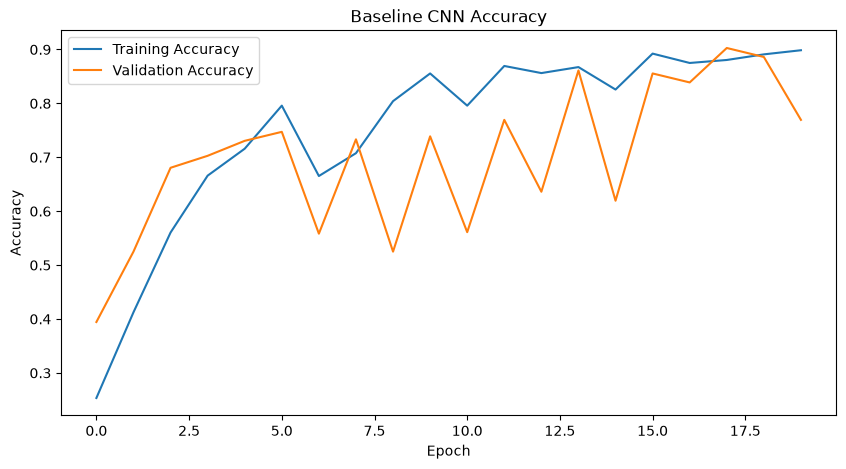

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

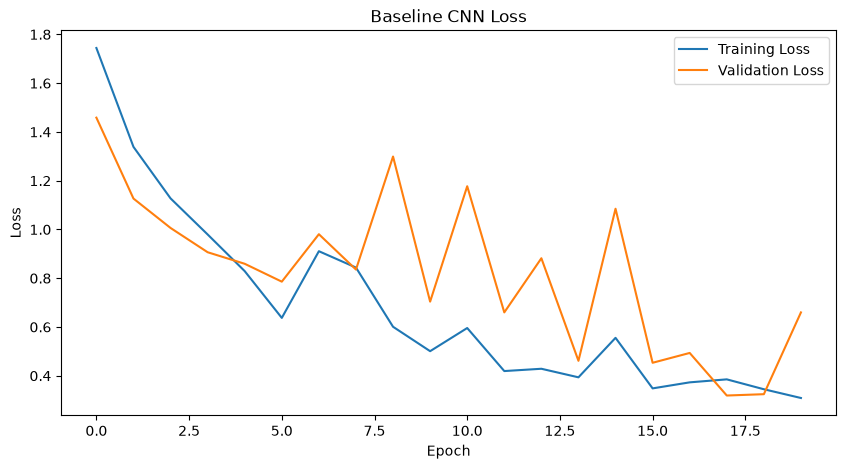

In [23]:
#Loss
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [24]:
#Evaluate Baseline:
test_loss, test_accuracy = model.evaluate(
    val_ds
)

print("Validation Loss:", test_loss)
print("Validation Accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 187ms/step - accuracy: 0.7694 - loss: 0.6598
Validation Loss: 0.6597959399223328
Validation Accuracy: 0.769444465637207


In [25]:
#Visualiose the learning curves

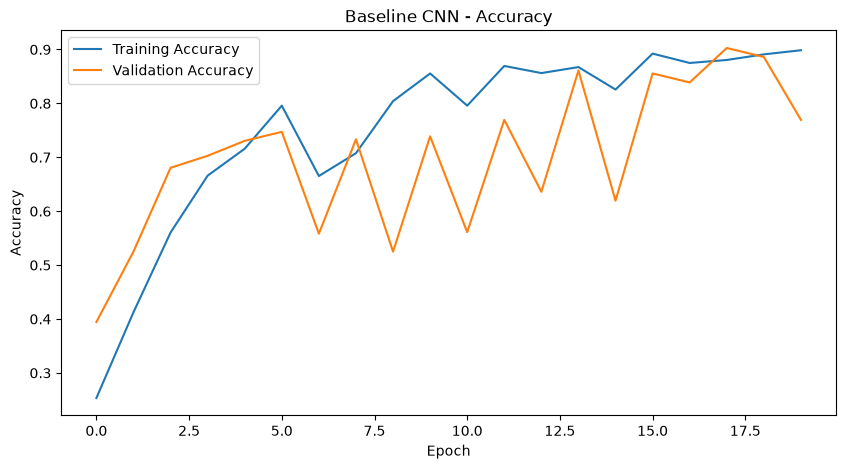

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Baseline CNN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

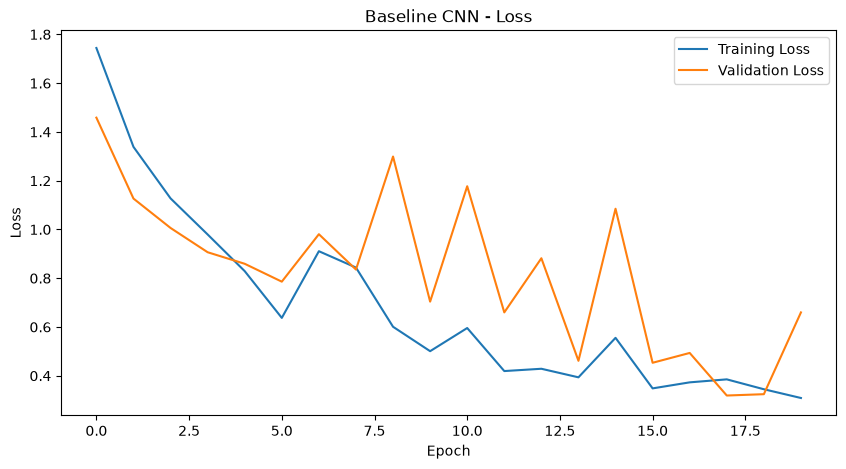

In [27]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Baseline CNN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [28]:
#Save the baseline model
model.save("baseline_cnn.keras")

In [29]:
#Genreate prediction
y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_labels
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [30]:
print("True labels:", y_true.shape)
print("Predicted labels:", y_pred.shape)

True labels: (360,)
Predicted labels: (360,)


In [33]:
#Classification Report
from sklearn.metrics import classification_report

In [34]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)

                 precision    recall  f1-score   support

        crazing       0.56      1.00      0.72        60
      inclusion       0.93      0.85      0.89        60
        patches       0.91      0.70      0.79        60
 pitted_surface       0.82      0.60      0.69        60
rolled-in_scale       0.71      0.78      0.75        60
      scratches       0.98      0.68      0.80        60

       accuracy                           0.77       360
      macro avg       0.82      0.77      0.77       360
   weighted avg       0.82      0.77      0.77       360



In [35]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix

In [36]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[60  0  0  0  0  0]
 [ 0 51  0  8  0  1]
 [18  0 42  0  0  0]
 [ 6  3  2 36 13  0]
 [13  0  0  0 47  0]
 [10  1  2  0  6 41]]


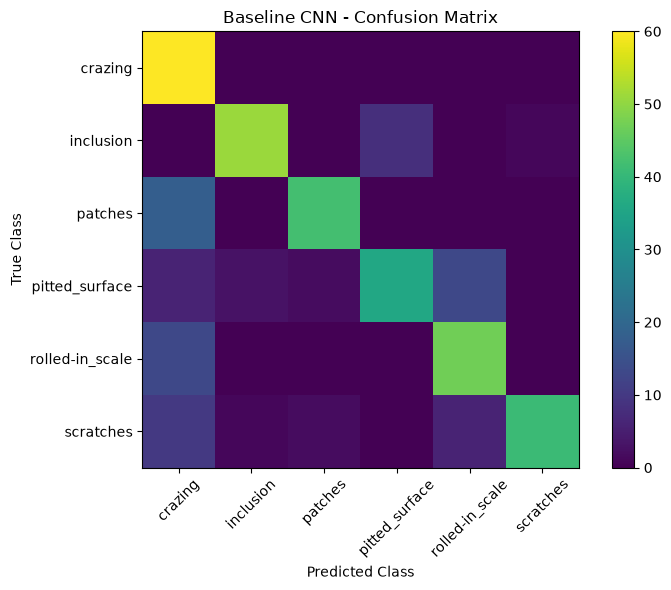

In [37]:
plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title("Baseline CNN - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45
)

plt.yticks(
    range(len(classes)),
    classes
)

plt.colorbar()

plt.tight_layout()
plt.show()